/opt/miniconda3/envs/data/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
[*********************100%***********************]  1 of 1 completed


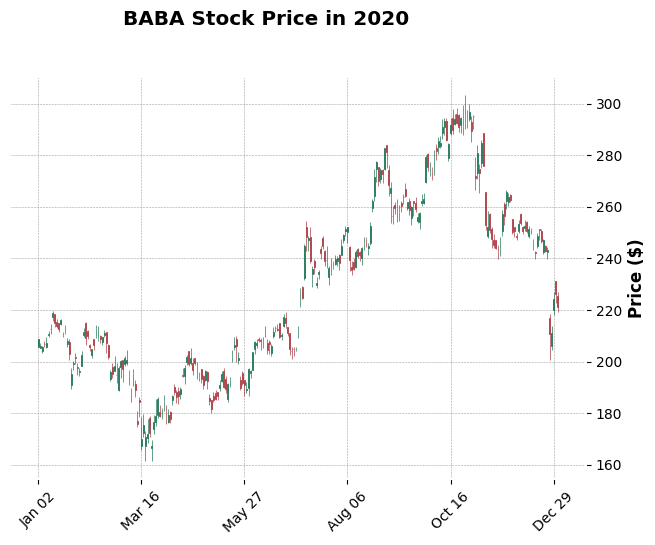

In [ ]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import os

BABA = yf.Ticker("BABA")
data = yf.download("BABA", start="2020-01-01", end="2021-01-01")
if isinstance(data.columns, pd.MultiIndex):
	data.columns = data.columns.get_level_values(0)
data.columns = [str(col).strip().title() for col in data.columns]
data = data.apply(pd.to_numeric, errors="coerce")
data = data.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
os.makedirs("./files", exist_ok=True)
data.to_csv("./files/BABA_2020.csv")
mpf.plot(data, type='candle', style='charles', title='BABA Stock Price in 2020', ylabel='Price ($)')
